In [1]:
import logging
logging.basicConfig(level=logging.WARNING)
root_logger = logging.getLogger()
root_logger.setLevel(logging.WARNING)
for name in ("transformers", "tokenizers", "torch"):
    logging.getLogger(name).setLevel(logging.WARNING)

import torch
import torch.nn as nn
import json
import os
import pandas as pd
from models.lstm_proj_diff import LSTM as LSTM2
from models.transformer import Transformer
from utils.dataset import TranslateDataset
from torch.utils.data import DataLoader
import tokenizers
import numpy as np
from tqdm import tqdm

In [2]:
np.exp(1.05)

np.float64(2.857651118063164)

In [3]:
df_eval = pd.read_parquet("data/tokenized_test.parquet").sample(frac=1,  random_state=42).reset_index(drop=True)
# df_eval = pd.read_parquet("data/tokenized_test.parquet").sample(n=100, random_state=42).reset_index(drop=True)

In [4]:
tokenizer = tokenizers.Tokenizer.from_file("artifacts/tokenizer_50000.json")

In [5]:
dataset_eval = TranslateDataset(
    tokens_src=df_eval['en_tokens_50000'].tolist(),
    tokens_tgt=df_eval['pt_tokens_50000'].tolist(),
    invert_src=False,
    max_len=30
)

dataloader_eval = DataLoader(dataset_eval, batch_size=256, shuffle=False)

In [6]:
MODELS_TRY = [
    LSTM2
]

In [ ]:
PATH_MODELS = "artifacts"

models = {}
for file in os.listdir(PATH_MODELS):
    if file.endswith(".pt"):
        model_name = file.split(".")[0].replace('model_', '')
        # keep only models with version >= 47
        try:
            ver = int(model_name.lstrip('v')) if model_name.startswith('v') else None
        except ValueError:
            ver = None
        if ver is None or ver not in (50, 65):
            continue
        print(f'Lendo {model_name}')
        model_path = os.path.join(PATH_MODELS, file)
        model_config_path = os.path.join("configs", f"{model_name}_config.json")
        
        with open(model_config_path, 'r', encoding='utf-8') as f:
            model_config = json.load(f)
        
        if 'architecture' in model_config and model_config['architecture'] == 'transformer':
            model = Transformer(
                embedding_dim=model_config["embedding_dim"],
                encoder_num_layers=model_config["encoder_num_layers"],
                decoder_num_layers=model_config["decoder_num_layers"],
                encoder_hidden_dim=model_config["encoder_hidden_dim"],
                decoder_hidden_dim=model_config["decoder_hidden_dim"],
                encoder_num_heads=model_config["encoder_num_heads"],
                decoder_num_heads=model_config["decoder_num_heads"],
                encoder_dropout=model_config["encoder_dropout"],
                decoder_dropout=model_config["decoder_dropout"],
                vocab_size=model_config["vocab_size"] if "vocab_size" in model_config else 50000,
                kv_cache=True,
                cross_attn_cache=True
            )
        else:
            model = LSTM2(embedding_dim=model_config["embedding_dim"],
                        encoder_bidirectional=model_config["encoder_bidirectional"],
                        encoder_hidden_dim=model_config["encoder_hidden_dim"],
                        encoder_num_layers=model_config["encoder_num_layers"],
                        decoder_hidden_dim=model_config["decoder_hidden_dim"],
                        decoder_num_layers=model_config["decoder_num_layers"],
                        encoder_dropout=model_config["encoder_dropout"],
                        decoder_dropout=model_config["decoder_dropout"],
                        vocab_size=model_config["vocab_size"] if "vocab_size" in model_config else 10000, 
                        attention = model_config["attention"] if "attention" in model_config else False,
                        pad_idx=0)
        model.load_state_dict(torch.load(model_path))
        model.to("cuda" if torch.cuda.is_available() else "cpu")
        model.eval()
        models[model_name] = model

Lendo v56
Lendo v65


In [8]:
# models = dict(reversed(list(models.items())))
print(models.keys())

dict_keys(['v56', 'v65'])


In [ ]:
from utils.metrics import compute_bleu, compute_rouge
from torch.nn.utils.rnn import pad_sequence

metrics_by_model = {}
batch_size_dict = {
    "v50": 256,
    "v65": 256
}

In [10]:
def corrigir_geracao_texto(list_tokens, tokenizer):
    new_list_tokens = []
    for tokens in list_tokens:
        new_tokens = []
        for token in tokens:
            if token == 6:
                break
            new_tokens.append(token)
        new_list_tokens.append(new_tokens)
    return new_list_tokens


In [11]:
for model_name, model in models.items():
    if model_name in metrics_by_model:
        print(f"Skipping {model_name} as it has already been evaluated.")
        continue
    print(f"Model: {model_name}")

    decoded_outputs = []
    reference_texts = []

    device = next(model.parameters()).device
    
    
    #printar a quantidade de parametros do modelo
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Number of parameters in {model_name}: {num_params}")

    batch_size = batch_size_dict[model_name]

    # Iterar manualmente pelo dataset e aplicar padding por batch
    n = len(dataset_eval)
    for start in tqdm(range(0, n, batch_size)):
        batch_items = [dataset_eval[i] for i in range(start, min(start + batch_size, n))]
        srcs = [item[0] for item in batch_items]
        tgts = [item[1] for item in batch_items]

        srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=0).to(device)
        tgts_padded = pad_sequence(tgts, batch_first=True, padding_value=0).to(device)

        tgt_tokens = tgts_padded[:, 1:]  # Remove o token de início

        # Decode ground-truth references (skip special tokens for metrics)
        reference_texts.extend(
            tokenizer.decode_batch(
                tgt_tokens.cpu().tolist(),
                skip_special_tokens=True
            )
        )

        with torch.no_grad():
            outputs = model.predict(
                src=srcs_padded,
                bos_token_id=5,
                eos_token_id=6,
                max_len=30,
                reset_cache=True,
                kv_cache=True
            )

        # Decode predictions (skip special tokens for metrics)
        tokens = tokenizer.decode_batch(
                        outputs,
                        skip_special_tokens=True
                    )
        decoded_outputs.extend(
            tokens
        )


    df_eval[f'{model_name}_pred'] = decoded_outputs


    # Compute metrics using utils/metrics
    try:
        bleu_res = compute_bleu(reference_texts, decoded_outputs)
    except Exception as e:
        bleu_res = {"error": str(e)}
    try:
        rouge_res = compute_rouge(reference_texts, decoded_outputs)
    except Exception as e:
        rouge_res = {"error": str(e)}

    metrics_by_model[model_name] = {"bleu": bleu_res, "rouge": rouge_res}
    print('BLEU:', bleu_res)
    print('ROUGE:', rouge_res)


Model: v56
Number of parameters in v56: 165422928


100%|██████████| 3193/3193 [03:48<00:00, 13.99it/s]


BLEU: {'bleu': 3.7658640200727227}
ROUGE: {'rouge1': {'precision': 0.28598968541595177, 'recall': 0.1958455592711323, 'fmeasure': 0.22731803106338372}, 'rouge2': {'precision': 0.11797398082716971, 'recall': 0.07793745995749125, 'fmeasure': 0.09120258462671052}, 'rougeL': {'precision': 0.27659732085983063, 'recall': 0.1901314642198211, 'fmeasure': 0.22033668121653796}}
Model: v65
Number of parameters in v65: 80675664


100%|██████████| 200/200 [07:38<00:00,  2.29s/it]


BLEU: {'bleu': 22.04487630528743}
ROUGE: {'rouge1': {'precision': 0.5043694196772076, 'recall': 0.6846372711662849, 'fmeasure': 0.5777239665503943}, 'rouge2': {'precision': 0.3481821867510816, 'recall': 0.493910375146162, 'fmeasure': 0.40544190472981406}, 'rougeL': {'precision': 0.49493207719365223, 'recall': 0.6720293725060239, 'fmeasure': 0.5669884846690956}}


In [16]:
import pandas as pd

# Converter dict de métricas para DataFrame (linhas = modelos)
df_metrics = pd.DataFrame.from_dict(metrics_by_model, orient='index')

# Helper seguro para navegar dicionários aninhados
def _safe_get(d, keys, default=None):
    try:
        v = d
        for k in keys:
            if not isinstance(v, dict):
                return default
            v = v.get(k)
        return v
    except Exception:
        return default

# Extrair BLEU (pode ser dict {'bleu': val} ou já um número em casos especiais)
df_metrics['bleu_score'] = df_metrics['bleu'].apply(lambda b: b.get('bleu') if isinstance(b, dict) and 'bleu' in b else (b if isinstance(b, (int, float)) else None))

# Extrair todas as subcolunas do ROUGE (rouge1, rouge2, rougeL)
for r in ['rouge1', 'rouge2', 'rougeL']:
    for m in ['precision', 'recall', 'fmeasure']:
        df_metrics[f'{r}_{m}'] = df_metrics['rouge'].apply(lambda x: _safe_get(x, [r, m]))

# Perplexity (já deve ser numérico) e limpeza básica
df_metrics['perplexity'] = df_metrics.get('perplexity').apply(lambda x: float(x) if x is not None else None) if 'perplexity' in df_metrics.columns else None

# Coluna auxiliar com recall do rouge2 para ordenação
df_metrics['rouge2_recall'] = df_metrics['rouge2_recall'] if 'rouge2_recall' in df_metrics.columns else df_metrics['rouge'].apply(lambda x: _safe_get(x, ['rouge2', 'recall']))

# Ordenar decrescentemente por recall do rouge2
df_metrics_sorted = df_metrics.sort_values('rouge2_recall', ascending=False)

df_metrics_sorted

,bleu,rouge,bleu_score,rouge1_precision,rouge1_recall,rouge1_fmeasure,rouge2_precision,rouge2_recall,rouge2_fmeasure,rougeL_precision,rougeL_recall,rougeL_fmeasure,perplexity
v65,{'bleu': 22.04487630528743},"{'rouge1': {'precision': 0.5043694196772076, '...",22.044876,0.504369,0.684637,0.577724,0.348182,0.493910,0.405442,0.494932,0.672029,0.566988,None
v56,{'bleu': 3.7658640200727227},"{'rouge1': {'precision': 0.28598968541595177, ...",3.765864,0.285990,0.195846,0.227318,0.117974,0.077937,0.091203,0.276597,0.190131,0.220337,None


In [17]:
df_n_parameters = pd.DataFrame({
    model_name: sum(p.numel() for p in model.parameters())
    for model_name, model in models.items()
}, index=['n_parameters']).T
df_n_parameters = df_n_parameters.reset_index().rename(columns={'index': 'name'})
df_n_parameters

,name,n_parameters
0,v56,165422928
1,v65,80675664


In [20]:
df_configs = pd.DataFrame([json.load(open(os.path.join("configs", f))) for f in os.listdir("configs") if f.endswith("_config.json")])
df_configs = df_configs.loc[df_configs['name'].isin(models.keys())].sort_values(by='name', ascending=False)
df_configs = df_configs[['name'] + df_configs.drop(columns='name').columns.tolist()]
df_configs = df_configs.merge(df_n_parameters, on='name', how='left')
df_configs

,name,invert_src,embedding_dim,encoder_hidden_dim,decoder_hidden_dim,encoder_num_layers,decoder_num_layers,encoder_dropout,decoder_dropout,encoder_bidirectional,...,label_smoothing,separate_embedding,tokenized_dir,tokenizer_path,num_workers,metadata_shuffle_buffer,npz_cache_size,seed,streaming_metadata,n_parameters
0,v65,False,512,512,512,4,4,0.1,0.1,False,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80675664
1,v56,False,384,1024,1024,3,3,0.1,0.1,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165422928


In [21]:
df_configs.to_dict(orient='records')

[{'name': 'v65',
  'invert_src': False,
  'embedding_dim': 512,
  'encoder_hidden_dim': 512,
  'decoder_hidden_dim': 512,
  'encoder_num_layers': 4,
  'decoder_num_layers': 4,
  'encoder_dropout': 0.1,
  'decoder_dropout': 0.1,
  'encoder_bidirectional': False,
  'batch_size': 192,
  'accum_steps': 2,
  'log_steps': 250,
  'save_steps': 1000,
  'eval_steps': 500,
  'device': 'cuda',
  'desc': 'Aumentando a quantidade de camadas do decoder para analisar o efeito',
  'early_stop_patience': 100,
  'early_stop_min_delta': 0.0,
  'warmup_steps': 1000.0,
  'max_steps': 500000.0,
  'learning_rate': 0.0001,
  'vocab_size': 50000.0,
  'max_len': 30.0,
  'clip_grad': nan,
  'init_weight_method': nan,
  'init_bias_method': nan,
  'teacher_forcing': True,
  'scheduler_sampling': False,
  'teacher_forcing_ratio': 1.0,
  'max_steps_scheduler_sampling': 50000.0,
  'curriculum_levels': [{'max_step': 500000,
    'max_len': 30,
    'batch_size': 192,
    'accum_steps': 2}],
  'attention': True,
  'archi

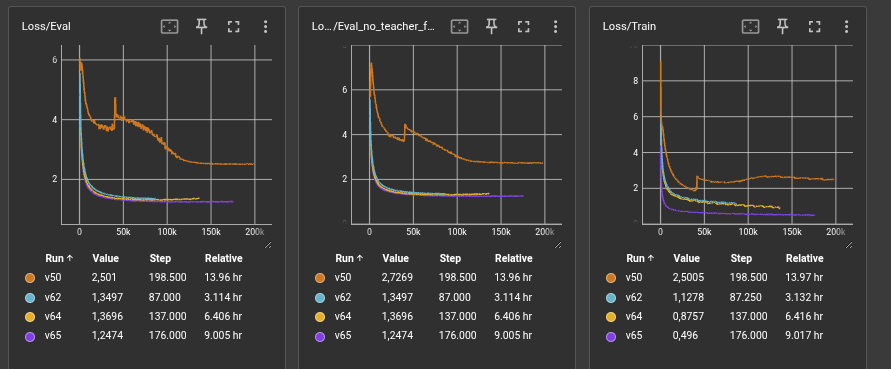

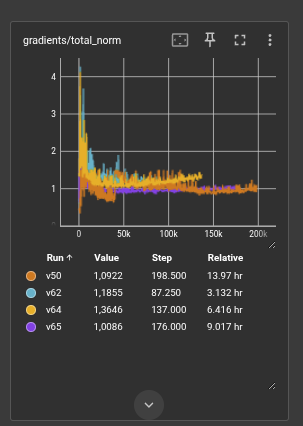

In [22]:
for index in np.random.choice(len(df_eval), size=100, replace=False):
    print('Inglês:', df_eval['en'].iloc[index])
    print('Português:', df_eval['pt'].iloc[index])
    for column in df_eval.columns:
        if('_pred' in column):
            model_test = column
            print(f'{model_test}:', df_eval[model_test].iloc[index])
    print('-'*200)

Inglês: Why don't you go to hyannis?
Português: - por que não vai à cidade?
v56_pred: <BOS>Por que não ?
v65_pred: <BOS>Por que não vai para hyannis ? <EOS>
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: - they have the big house on the drive.
Português: - eles têm uma grande casa na avenida.
v56_pred: <BOS>- eles têm a casa .
v65_pred: <BOS>- eles têm a casa grande na estrada . <EOS>
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: You know how to use cell phone?
Português: Sabe como se usa um celular?
v56_pred: <BOS>A mãe chama .
v65_pred: <BOS>Você sabe como usar o celular ? <EOS>
---------------------------------------------------------------------------------------